In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
df = pd.read_csv("/content/Nassau Candy Distributor.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (10194, 18)


In [3]:
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,3/1/2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,5/1/2024,5/7/2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [5]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [6]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

display(missing)

,Missing Count,Missing Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Country/Region,0,0.0
City,0,0.0
State/Province,0,0.0
Postal Code,0,0.0


In [8]:
print(
    "Duplicate complete rows:",
    df.duplicated().sum()
)
print(
    "Duplicate Row IDs:",
    df["Row ID"].duplicated().sum()
)

Duplicate complete rows: 0
Duplicate Row IDs: 0


In [9]:
print(df.dtypes)

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


In [10]:
print("Categorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nNumerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Categorical columns:
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name']

Numerical columns:
['Row ID', 'Customer ID', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [11]:
numeric_cols = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost"
]

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Sales,10194.0,13.908537,11.341020,1.25,7.2,10.80,18.00,260.0
Units,10194.0,3.791838,2.228317,1.00,2.0,3.00,5.00,14.0
Gross Profit,10194.0,9.166451,6.643740,0.25,4.9,7.47,12.25,130.0
Cost,10194.0,4.742087,5.061647,0.60,2.4,3.60,5.70,130.0


In [12]:
for col in numeric_cols:
    print(
        col,
        "negative values:",
        (df[col] < 0).sum()
    )

Sales negative values: 0
Units negative values: 0
Gross Profit negative values: 0
Cost negative values: 0


In [13]:
df["Calculated Gross Profit"] = (
    df["Sales"] - df["Cost"]
)

df["Profit Difference"] = (
    df["Gross Profit"] -
    df["Calculated Gross Profit"]
)

print(
    "Gross Profit mismatches:",
    (df["Profit Difference"].abs() > 0.01).sum()
)

Gross Profit mismatches: 0


In [14]:
df["Order Date Raw"] = df["Order Date"].astype(str).str.strip()
df["Ship Date Raw"] = df["Ship Date"].astype(str).str.strip()

In [15]:
print("Order Date examples:")
print(df["Order Date Raw"].head(20).to_string())

print("\nShip Date examples:")
print(df["Ship Date Raw"].head(20).to_string())

Order Date examples:
0      3/1/2024
1      4/1/2024
2      4/1/2024
3      4/1/2024
4      5/1/2024
5      6/1/2024
6      6/1/2024
7      6/1/2024
8      6/1/2024
9      6/1/2024
10     6/1/2024
11     6/1/2024
12     6/1/2024
13     6/1/2024
14     7/1/2024
15     7/1/2024
16     9/1/2024
17     9/1/2024
18    10/1/2024
19    10/1/2024

Ship Date examples:
0     30-06-2026
1       1/7/2026
2       1/7/2026
3       1/7/2026
4       5/7/2026
5       3/7/2026
6       3/7/2026
7     30-06-2026
8       3/7/2026
9       3/7/2026
10      3/7/2026
11      1/7/2026
12      3/7/2026
13      3/7/2026
14      5/7/2026
15      5/7/2026
16      6/7/2026
17      6/7/2026
18      8/7/2026
19      8/7/2026


In [16]:
df["Order Date Parsed"] = pd.to_datetime(
    df["Order Date Raw"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df["Ship Date Parsed"] = pd.to_datetime(
    df["Ship Date Raw"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [17]:
print(
    "Order Date parsing failures:",
    df["Order Date Parsed"].isna().sum()
)

print(
    "Ship Date parsing failures:",
    df["Ship Date Parsed"].isna().sum()
)

Order Date parsing failures: 0
Ship Date parsing failures: 0


In [19]:
df["Lead Time Days"] = (
    df["Ship Date Parsed"] -
    df["Order Date Parsed"]
).dt.days
print(df["Lead Time Days"].describe())

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time Days, dtype: float64


In [20]:
print(
    "Missing Lead Times:",
    df["Lead Time Days"].isna().sum()
)

print(
    "Negative Lead Times:",
    (df["Lead Time Days"] < 0).sum()
)

Missing Lead Times: 0
Negative Lead Times: 0


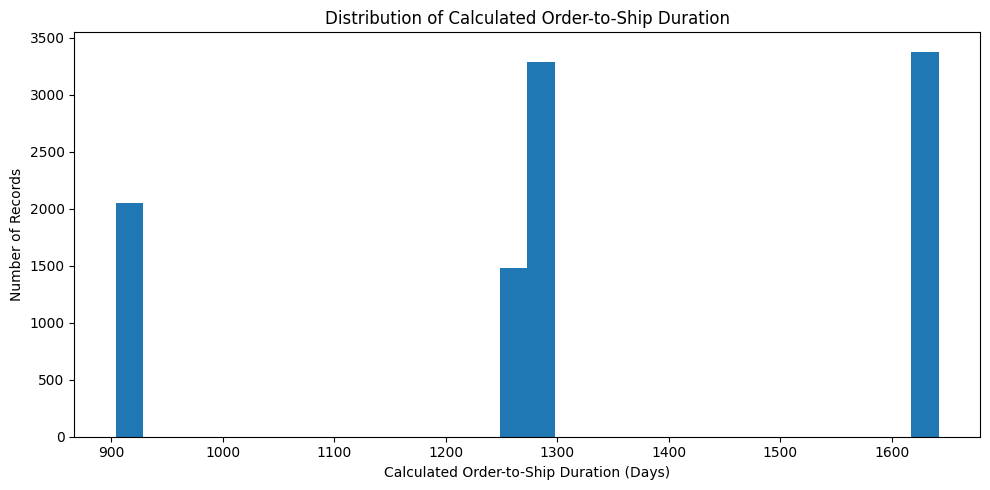

In [21]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Lead Time Days"],
    bins=30
)

plt.xlabel("Calculated Order-to-Ship Duration (Days)")
plt.ylabel("Number of Records")
plt.title("Distribution of Calculated Order-to-Ship Duration")

plt.tight_layout()
plt.show()

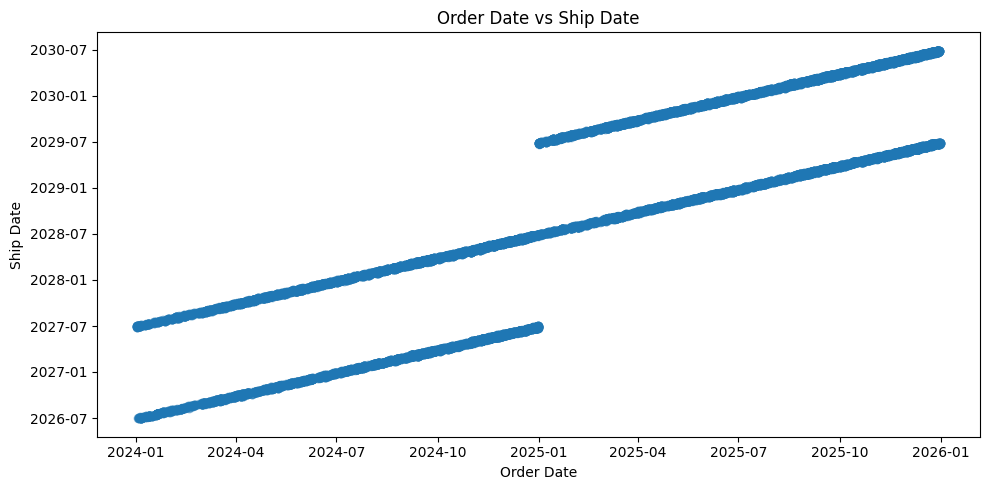

In [22]:
plt.figure(figsize=(10,5))

plt.scatter(
    df["Order Date Parsed"],
    df["Ship Date Parsed"],
    alpha=0.5
)

plt.xlabel("Order Date")
plt.ylabel("Ship Date")
plt.title("Order Date vs Ship Date")

plt.tight_layout()
plt.show()

In [23]:
df["Profit Margin"] = np.where(
    df["Sales"] != 0,
    df["Gross Profit"] / df["Sales"] * 100,
    0
)

In [24]:
df["Sales per Unit"] = (
    df["Sales"] / df["Units"]
)

df["Profit per Unit"] = (
    df["Gross Profit"] / df["Units"]
)

In [25]:
df["Order Year"] = (
    df["Order Date Parsed"].dt.year
)

df["Order Month"] = (
    df["Order Date Parsed"].dt.month
)

df["Order Quarter"] = (
    df["Order Date Parsed"].dt.quarter
)

df["Order DayOfWeek"] = (
    df["Order Date Parsed"].dt.dayofweek
)

In [26]:
print("=" * 50)
print("FINAL DATA AUDIT")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(
    "Total missing values:",
    df.isnull().sum().sum()
)

print(
    "Negative lead times:",
    (df["Lead Time Days"] < 0).sum()
)

print(
    "Duplicate complete rows:",
    df.duplicated().sum()
)

FINAL DATA AUDIT
Rows: 10194
Columns: 32
Total missing values: 0
Negative lead times: 0
Duplicate complete rows: 0


In [27]:
df.to_csv(
    "nassau_candy_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
